# CASE STUDY : ANALYZE NETFLIX & STRATRGY TIMELINE RECOMMENDATION

## A. OVERVIEW DATA & PREPARE 

### OVERVIEW DATA

| Column Name    | Description                                                                                                                 |
| -------------- | --------------------------------------------------------------------------------------------------------------------------- |
| `show_id`      | Unique identifier for each show or movie in the dataset. Example: `s1`, `s2`.                                               |
| `type`         | Indicates whether the entry is a **Movie** or a **TV Show**.                                                                |
| `title`        | Title of the movie or TV show.                                                                                              |
| `director`     | Name(s) of the director(s). Empty if not available.                                                                         |
| `cast`         | List of main cast members separated by commas. Empty if not available.                                                      |
| `country`      | Country where the content was produced or released.                                                                         |
| `date_added`   | The date the content was added to the platform (e.g., Netflix). Format: `"Month Day, Year"`.                                |
| `release_year` | The year the movie or show was originally released.                                                                         |
| `rating`       | Content rating (e.g., `PG-13`, `TV-MA`). Shows which audience group it is appropriate for.                                  |
| `duration`     | For movies: duration in minutes (e.g., `90 min`). For TV shows: number of seasons (e.g., `2 Seasons`).                      |
| `listed_in`    | Categories or genres the content belongs to (e.g., `TV Dramas`, `Crime TV Shows`). Multiple genres are separated by commas. |
| `description`  | A short summary or synopsis of the movie or show.                                                                           |

### IMPORT LIBRAIES PYTHON

In [93]:
# import libraries Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
import squarify
# import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

#Color palette of Netflix
netflix_palette = [
    "#c62222",  # Strong Red
    "#ebd4d3",  # Light Rose
    "#940404",  # Deep Crimson
    "#a66968",  # Dusty Rose
    "#8d9d9a",  # Muted Teal
    "#3a4749"   # Charcoal Teal
]

netflix_palette_extended = [
    "#940404",  # Deep Crimson
    "#e50914",  # Netflix Red
    "#b81d24",  # Darker Red
    "red",  # Strong Red
    "#a66968",  # Dusty Rose
    "#ebd4d3",  # Light Rose
    "#8d9d9a",  # Muted Teal
    "#6d6d6e",  # Mid gray
    "#8c8c8c",  # Light gray
    "#3a3a3a",  # Charcoal
    "#221f1f"  # Netflix Black
]


### DATASET PREPARATION
#### 1. CHECK DATASET
- Check head data
- Check data info
- Fill null values with 'Unknow'
- Check duplicate data

In [57]:
# read given csv file
df = pd.read_csv('netflix_data_study_case.csv')

In [58]:
# check the first 5 row of the dataset
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [59]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


From the table above, the dataset has 8807 rows and 12 columns. We can indicate columns which have missing value by comparing the counted value with the number of row. Columns with missing value are: director, cast, country, date_added, rating and duration

In [60]:
# Fill null values with 'Unknow'
df = df.assign(
    director=df['director'].fillna('Unknown'),
    cast=df['cast'].fillna('Unknown'),
    country=df['country'].fillna('Unknown'),
    rating=df['rating'].fillna('Unknown'),
    duration=df['duration'].fillna('Unknown')
)

In [61]:
# Categorize features: converts the type column in the DataFrame into a categorical data type.
df['type'] = df['type'].astype('category')

#### 2. CHECK DUPLICATE VALUES
In this part, I check the duplicate values by using excel to check the title along with other columns. Using compositions key to check the duplicates is also on the table, however, from the dataset, it is not always guarantee the same movie being show twice will have the same value for all the columns.

In [62]:
# TESTTING: CHECK THESE ID
Check_0 = df[df['show_id'].isin(['s3997', 's5965', 's4523', 's5966', 's3963', 's5967', 's5304', 's6706', 's160', 's7346', 's1271', 's8022', 's6530', 's3372'])]
print(Check_0)

     show_id     type                     title            director  \
159     s160    Movie            Love in a Puff      Pang Ho-cheung   
1270   s1271  TV Show  Sin senos sí hay paraíso             Unknown   
3371   s3372    Movie              Consequences        Ozan Açıktan   
3962   s3963    Movie                 15 August  Swapnaneel Jayakar   
3996   s3997  TV Show                February 9             Unknown   
4522   s4523    Movie                   22 July     Paul Greengrass   
5303   s5304    Movie                Manoranjan       Shammi Kapoor   
5964   s5965  TV Show                    Feb-09             Unknown   
5965   s5966    Movie                    22-Jul     Paul Greengrass   
5966   s5967    Movie                    15-Aug  Swapnaneel Jayakar   
6529   s6530    Movie             Consequences         Ozan Açıktan   
6705   s6706    Movie      Esperando La Carroza     Alejandro Doria   
7345   s7346    Movie            Love In A Puff      Pang Ho-cheung   
8021  

In [63]:
# Create new column "Format Title"
df["Format Title"] = df["title"].str.lower().str.strip()
Check_1 = df[df["Format Title"].duplicated(keep=False)]
print(set(Check_0['show_id']) - set(Check_1['show_id']))
print(set(Check_1['show_id']) - set(Check_0['show_id']))

{'s3997', 's5304', 's3963', 's8022', 's5966', 's5965', 's5967', 's4523'}
{'s5319', 's304', 's5034', 's5096', 's5752', 's8023'}


After reviewing the data carefully, I decided to drop the following show IDs: s6530, s5967, s5966, and s5965

In [64]:
show_ids_to_drop = ['s6530', 's5967', 's5966', 's5965']
df = df[~df['show_id'].isin(show_ids_to_drop)]
print('Dataset after remove outlier: ', df.shape[0])

Dataset after remove outlier:  8803


#### 3. Explain and mapping the values in rating
| Rating | Meaning |
|--------|---------|
| TV-MA  | Mature Audience. Not suitable for children under 17. |
| TV-14  | Parents strongly cautioned. May be unsuitable for children under 14. |
| TV-PG  | Parental guidance suggested. Some material may not be suitable. |
| TV-Y7  | Directed to older children age 7 and above. |
| TV-Y   | Appropriate for all children. |
| PG     | Parental Guidance suggested (Movies). |
| PG-13  | Parents strongly cautioned. Some material may be inappropriate < 13. |
| R      | Restricted. Under 17 requires accompanying adult (Movies). |
| G      | General Audience. Suitable for all ages. |
| NC-17  | Adults only. No one 17 and under admitted. |
| NR/UR  | Not Rated / Unrated. No official rating provided. |


In [65]:
rating_category_map = { 'TV-Y': 'Kids','TV-Y7': 'Kids','G': 'Kids','TV-G': 'Kids',
    'PG': 'Pre-Teens','TV-PG': 'Pre-Teens','PG-13': 'Teenagers',
    'TV-14': 'Teenagers','R': 'Adults','TV-MA': 'Adults','NC-17': 'Adults',
    'NR': 'Unrated','UR': 'Unrated','Unknown': 'Unrated'}

# Map directly from 'rating' to category without creating a normalized column
df['audience_category'] = df['rating'].astype(str).str.upper().str.strip().map(rating_category_map).fillna('Unrated')

#### 4. Datetime Data Convertion

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8803 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   show_id            8803 non-null   object  
 1   type               8803 non-null   category
 2   title              8803 non-null   object  
 3   director           8803 non-null   object  
 4   cast               8803 non-null   object  
 5   country            8803 non-null   object  
 6   date_added         8793 non-null   object  
 7   release_year       8803 non-null   int64   
 8   rating             8803 non-null   object  
 9   duration           8803 non-null   object  
 10  listed_in          8803 non-null   object  
 11  description        8803 non-null   object  
 12  Format Title       8803 non-null   object  
 13  audience_category  8803 non-null   object  
dtypes: category(1), int64(1), object(12)
memory usage: 971.5+ KB


In [67]:
# Clean and format the date values into a standard format
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

# Extracted month and year from the date_added column
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month_name()

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Format Title,audience_category,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",dick johnson is dead,Teenagers,2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",blood & water,Adults,2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,ganglands,Adults,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",jailbirds new orleans,Adults,2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,kota factory,Adults,2021,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",zodiac,Adults,2019,November
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",zombie dumb,Kids,2019,July
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,zombieland,Adults,2019,November
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",zoom,Pre-Teens,2020,January


In [68]:
# After I clean the date column, I want to check: 
# 1. The number of missing value matching with the number show in the information of the data frame
# 2. The missing value is correctly assign
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Format Title,audience_category,year_added,month_added
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ...",a young doctor's notebook and other stories,Adults,<NA>,NaN
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...,anthony bourdain: parts unknown,Pre-Teens,<NA>,NaN
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...,frasier,Pre-Teens,<NA>,NaN
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...,friends,Teenagers,<NA>,NaN
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe...",gunslinger girl,Teenagers,<NA>,NaN
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...,kikoriki,Kids,<NA>,NaN
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder...",la familia p. luche,Teenagers,<NA>,NaN
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews...",maron,Adults,<NA>,NaN
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil...",red vs. blue,Unrated,<NA>,NaN
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ...",the adventures of figaro pho,Kids,<NA>,NaN


#### 5. Check if any entries labeled as "Movie" contain the word "Season" in the duration, and vice versa for "TV Show"
This is a simple step for data-quality check. Normally, if a product labelled as 'Movies' then we are expecting the duration should be '93 min' or '120 min'. This apply the same for 'TV Shows' where the duration should be count in season not minute. If the value 'type' column and 'duration' column does not match then the that row does not have meaningful value. 

In [69]:
movie_with_season = df[(df['type'] == 'Movie') & (df['duration'].str.contains('Season', na=False))]
tv_without_season = df[(df['type'] == 'TV Show') & (~df['duration'].str.contains('Season', na=False))]

print(f'There are {len(movie_with_season)} contain Season in Movie')
print(f'There are {len(tv_without_season)} not contain Season in TV Show')

There are 0 contain Season in Movie
There are 0 not contain Season in TV Show


Check for rows where the 'rating' column contains duration-like values (e.g., minutes), which should be cleaned here to avoid misinterpretation in later analysis (rating analysis)

In [70]:
# Check for rows where the rating column appears to be a duration (ends with "min")
rating_as_duration = df[df['rating'].str.contains(r'^\d+\s*min$', na=False)]
rating_as_duration[['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,Unknown
5794,Louis C.K.: Hilarious,Movie,84 min,Unknown
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,Unknown


In [71]:
# Set the rating to "Unknown" for those rows and display
df.loc[rating_as_duration.index, 'duration'] = df.loc[rating_as_duration.index, 'rating']
df.loc[rating_as_duration.index, 'rating'] = 'Unknown'
df.loc[rating_as_duration.index, ['title', 'type', 'rating', 'duration']]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,Unknown,74 min
5794,Louis C.K.: Hilarious,Movie,Unknown,84 min
5813,Louis C.K.: Live at the Comedy Store,Movie,Unknown,66 min


#### 6. Split the 'listed_in' column by comma to create a list of genres for each entry

In [72]:
df['genres'] = df['listed_in'].str.split(', ')

#### 7. LABEL SINGLE vs MULTIPLE GENRES

In [73]:
# Count number of genres per title
df['num_genres'] = df['genres'].apply(len)

# Label as Single or Multiple
df['genre_type'] = df['num_genres'].apply(lambda x: 'Multiple' if x > 1 else 'Single')

Now that the dataset is cleaned and ready for EDA, let's take another look at the first ten rows.

In [74]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Format Title,audience_category,year_added,month_added,genres,num_genres,genre_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",dick johnson is dead,Teenagers,2021,September,[Documentaries],1,Single
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",blood & water,Adults,2021,September,"[International TV Shows, TV Dramas, TV Mysteries]",3,Multiple
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,ganglands,Adults,2021,September,"[Crime TV Shows, International TV Shows, TV Ac...",3,Multiple
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",jailbirds new orleans,Adults,2021,September,"[Docuseries, Reality TV]",2,Multiple
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,kota factory,Adults,2021,September,"[International TV Shows, Romantic TV Shows, TV...",3,Multiple
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,midnight mass,Adults,2021,September,"[TV Dramas, TV Horror, TV Mysteries]",3,Multiple
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,my little pony: a new generation,Pre-Teens,2021,September,[Children & Family Movies],1,Single
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",sankofa,Adults,2021,September,"[Dramas, Independent Movies, International Mov...",3,Multiple
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,the great british baking show,Teenagers,2021,September,"[British TV Shows, Reality TV]",2,Multiple
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,the starling,Teenagers,2021,September,"[Comedies, Dramas]",2,Multiple


### EXPLORATION DATA ANALYSIS (CURRENT STATE OF NETFLIX)
1. Content Analysis
* Type Analysis: Has Netflix been increasingly focusing on TV shows rather than movies in recent years?
* Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?
* Multi-genre or single genre?
* Age-Based Netflix Rating Analysis: Is there enough content for kids and adults? Are there any gaps in the market where we could grow?
* Also, has there been any recent trend showing that Netflix is shifting its focus more toward kids' content?
* So, let’s investigate whether there is a relationship between audience age group and genre. Which genres does Netflix focus on for each specific age group?

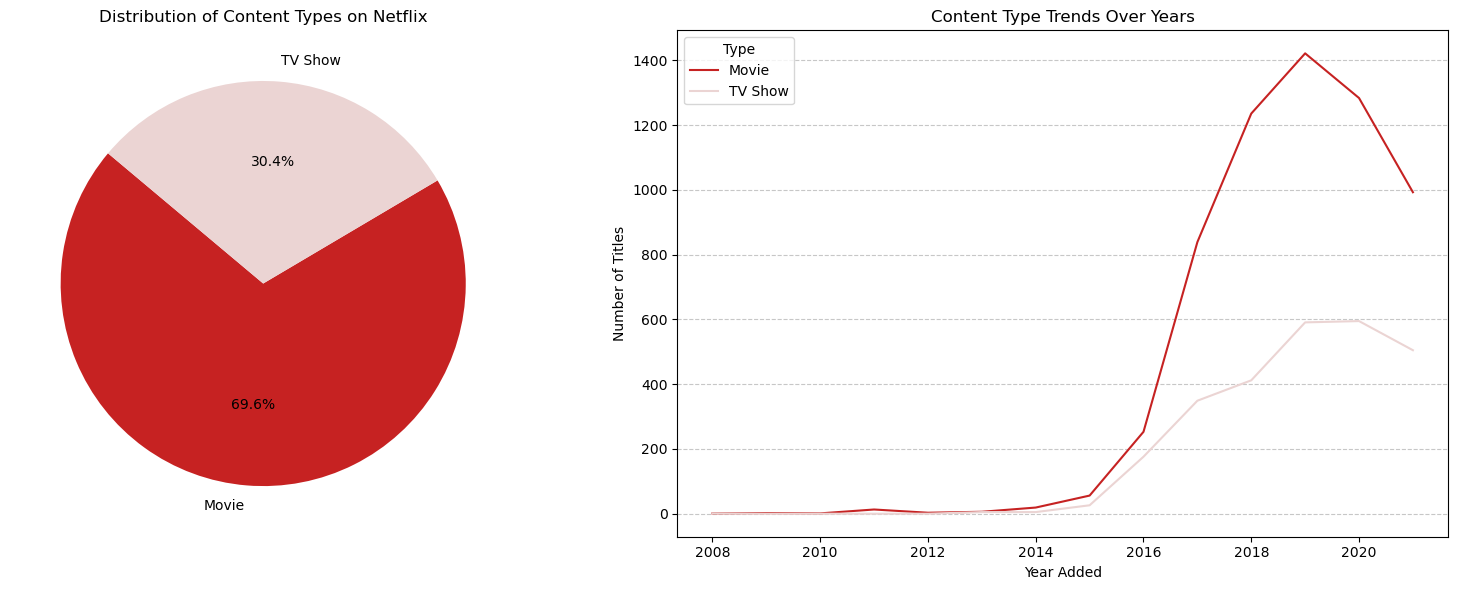

In [75]:
# 1. Type Analysis: Has Netflix been increasingly focusing on TV shows rather than movies in recent years?
type_counts = df['type'].value_counts()
type_by_year = df.groupby(['year_added', 'type'], observed=True).size().unstack(fill_value=0)

# Pie chart and Line chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140,colors=netflix_palette[:len(type_counts)])
axes[0].set_title('Distribution of Content Types on Netflix')

type_by_year.plot(ax=axes[1],color=netflix_palette[:len(type_by_year.columns)])
axes[1].set_title('Content Type Trends Over Years')
axes[1].set_xlabel('Year Added')
axes[1].set_ylabel('Number of Titles')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Type')
plt.tight_layout()
plt.show()


##### 1.1. Type Analysis: Has Netflix been increasingly focusing on TV shows rather than movies in recent years?
Based on the data shown, no — Netflix has not been increasingly focusing on TV shows. Movies still dominate both in total catalogue share and in yearly additions.

###### Catalogue Share:
- Movies make up 69.6% of all content.
- TV Shows account for 30.4%.
- This indicates a continued emphasis on movies overall.
###### Trends Over Time (2008–2014):
- Movies and TV Shows grew at similar, modest rates.
- No sign of a shift toward TV shows during this period.
###### 2014–2019:
- Movies experienced rapid growth, peaking at over 1,400 titles in 2019.
- TV Shows increased too, but at a much slower and steadier pace.
- The gap between Movies and TV Shows widened, not narrowed.
###### Post‑2019 Decline:
- Both categories declined, but the decline does not indicate a shift toward TV shows — it reflects an overall reduction in new additions.

###### Conclusion
The data clearly shows that Netflix has expanded its movie catalogue far more aggressively than its TV show catalogue, especially between 2014 and 2019. While TV shows have grown, they have not overtaken or even approached the scale of movie additions. Therefore, the evidence does not support the idea that Netflix has been increasingly focusing on TV shows in recent years.

##### 1.2. Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?

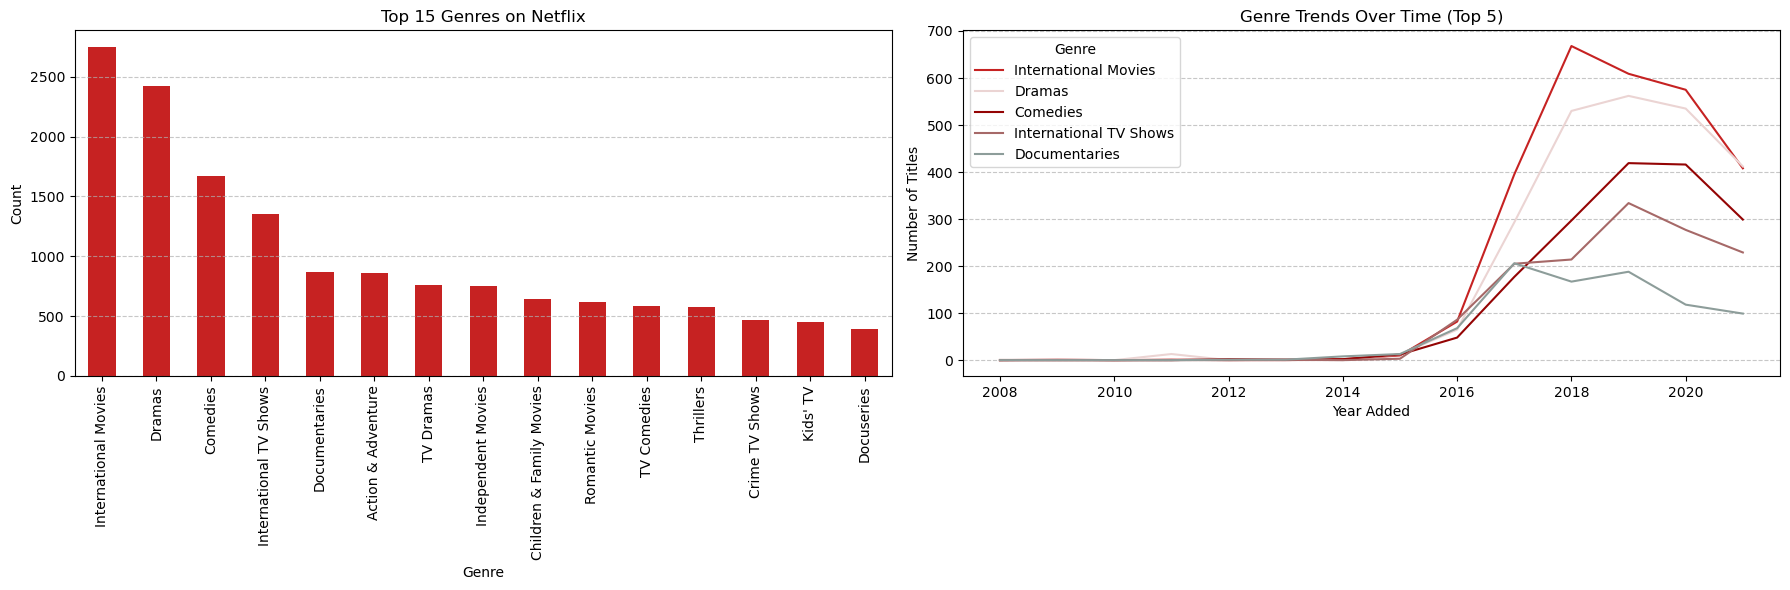

In [83]:
# 1.2a. Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?

# Explode the list so each genre is in its own row
df_exploded = df.explode('genres')

# Plotting column chart and line chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Count
genre_counts = df_exploded['genres'].value_counts()

# Bar chart (top 15 genres)
genre_counts.head(15).plot(kind='bar', ax=axes[0],color=netflix_palette[0])
axes[0].set_title('Top 15 Genres on Netflix')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7) 
axes[0].tick_params(axis='x', rotation=90)

# Group by year and genre for line chart
genre_by_year = df_exploded.dropna(subset=['year_added']).groupby(['year_added', 'genres']).size().unstack(fill_value=0)

# Line chart (trend of top 5 genres)
top_genres = genre_counts.head(5).index
genre_by_year[top_genres].plot(ax=axes[1],color=netflix_palette[:5])
axes[1].set_title('Genre Trends Over Time (Top 5)')
axes[1].set_xlabel('Year Added')
axes[1].set_ylabel('Number of Titles')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Genre')
plt.tight_layout()
plt.show()


##### 1.2a. Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?

###### In bar chart:

- International Movies, Dramas, and Comedies dominate the platform.

- International TV Shows and TV Shows are strong but noticeably behind movies.

- There’s a mix of adult-oriented genres (e.g., Thrillers, Crime TV Shows) and family/kids content (Children & Family Movies, Kids' TV). This may signal opportunities to expand in these genres where Netflix has relatively fewer offerings.

###### In line chart:

- All genres saw rapid growth post-2015 (except Documentaries), peaking around 2018–2019.

- International Movies led the surge, peaking around 2018 with nearly 700 titles.Dramas and Comedies followed closely, peaking shortly after.

- Documentaries had the slowest and most stable growth, with a visible decline post-2019.


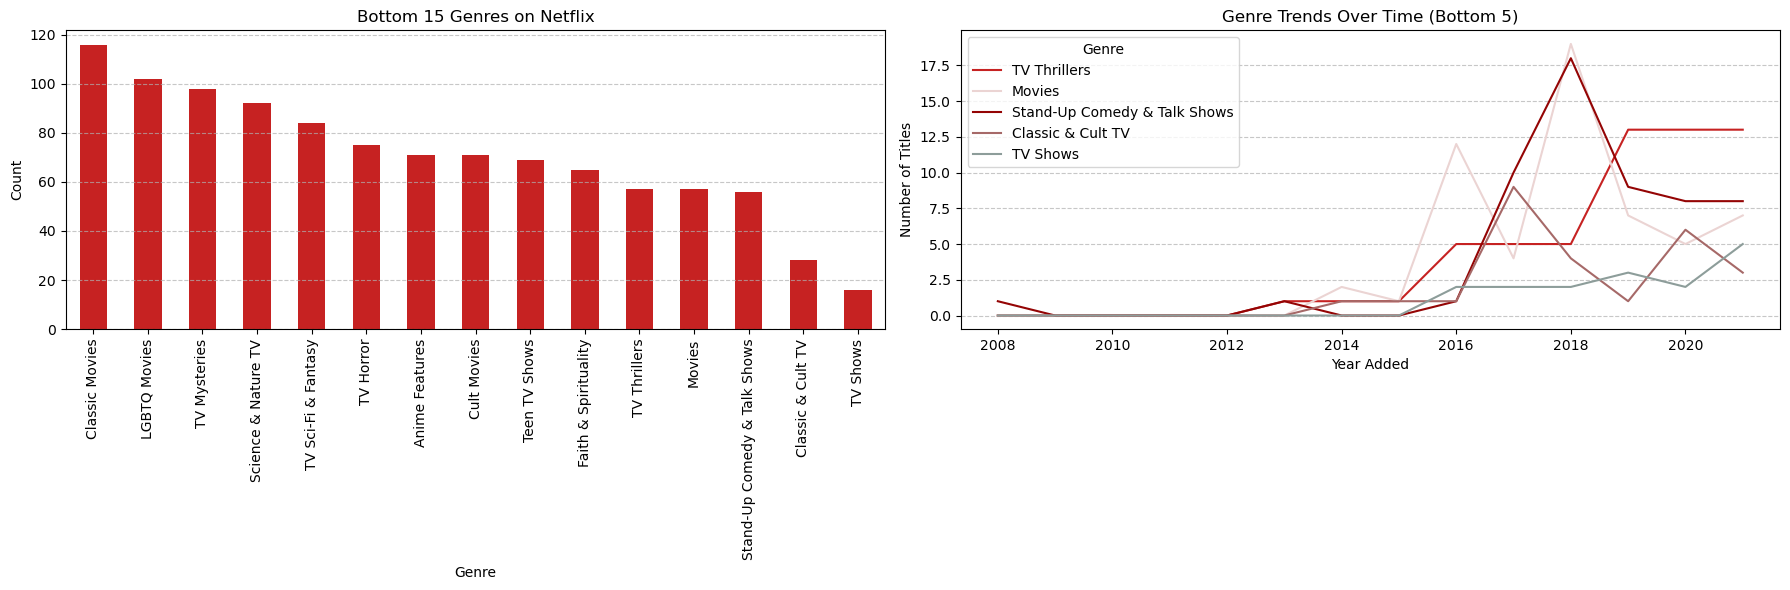

In [84]:
# 1.2b. Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?

# Plotting column chart and line chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart (top 15 genres)
genre_counts.tail(15).plot(kind='bar', ax=axes[0],color=netflix_palette[0])
axes[0].set_title('Bottom 15 Genres on Netflix')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=90)

# Line chart (trend of top 5 genres)
top_genres = genre_counts.tail(5).index
genre_by_year[top_genres].plot(ax=axes[1],color=netflix_palette[:5])
axes[1].set_title('Genre Trends Over Time (Bottom 5)')
axes[1].set_xlabel('Year Added')
axes[1].set_ylabel('Number of Titles')
axes[1].legend(title='Genre')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### 1.2b. Genre Analysis: How the genre distribution on the platform (Top genres and Bottom genres)? Which genre is the most popular nowaday?
###### In the bar chart:

- Genres like Classic Movies, LGBTQ Movies, TV Mysteries, Science & Nature TV, and TV Sci-Fi & Fantasy are among the least produced.

- Surprisingly, categories like Teen TV Shows, Faith & Spirituality, and TV Horror are also underrepresented.

- Genres such as Stand-Up Comedy & Talk Shows and Classic & Cult TV are extremely rare.

###### In the line chart:

- None of the bottom genres exhibit strong upward trends.

- TV Thrillers and Stand-Up Comedy & Talk Shows peaked around 2018, then flatlined or declined. Classic & Cult TV and TV Shows had minimal growth.

##### 1.3. Multi-genre or single genre?

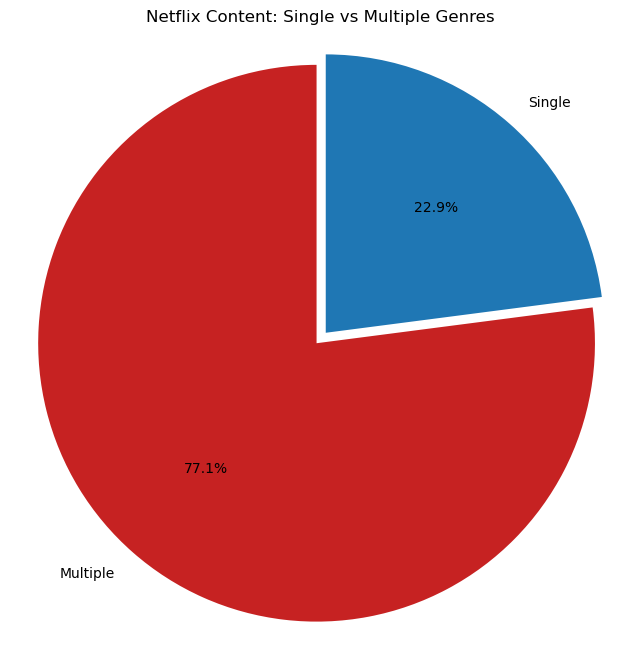

In [85]:
# 1.3 Multi-genre or single genre?
# Distribution
genre_dist = df['genre_type'].value_counts()
genre_pct = df['genre_type'].value_counts(normalize=True) * 100

# Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(genre_pct, labels=genre_pct.index, autopct='%1.1f%%', 
        colors=[netflix_palette[0], '#1F77B4'], startangle=90, explode=(0.05, 0))
plt.title('Netflix Content: Single vs Multiple Genres')
plt.axis('equal')
plt.show()

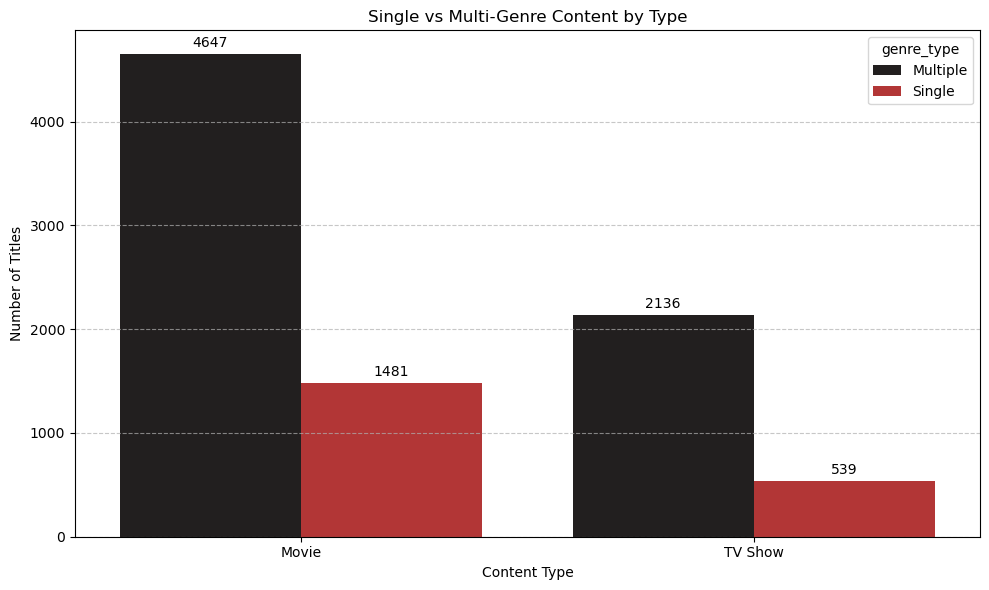

In [87]:
# Genre classification
# Group by content type and genre type with observed=True
genre_type_distribution = df.groupby(['type', 'genre_type'], observed=True)['title'].count().reset_index()

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=genre_type_distribution, x='type', y='title', hue='genre_type', palette=['#221f1f', netflix_palette[0]])
plt.title('Single vs Multi-Genre Content by Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

##### 1.3 Multi-genre or single genre?
###### Pie Chart
- Dominance of Multi-Genre Content: 77.1% of all titles in the dataset are classified as Multiple Genres (6,792 titles), while only 22.9% are Single Genre (2,011 titles).
- Netflix's Blended Approach: The platform heavily relies on titles that combine multiple genres (e.g., "International TV Shows + TV Dramas + TV Mysteries"), making the catalogue feel complex and less focused.
- 
###### Bar Chart
- Movies Are More Multi-Genre: Out of all Movies, 4,647 are Multiple Genres vs only 1,481 Single Genre — meaning ~76% of movies are blended.

- TV Shows Are Also Mostly Multi-Genre: 2,136 TV Shows are Multiple Genres compared to 539 Single Genre — approximately 80% of TV Shows use multiple genre labels.

- Slightly Higher Multi-Genre Rate in TV Shows: TV Shows show a marginally higher proportion of multi-genre content than Movies, reinforcing Netflix’s preference for blended storytelling.

##### 1.4. Age-Based Netflix Rating Analysis: Is there enough content for kids and adults? Are there any gaps in the market where we could grow?

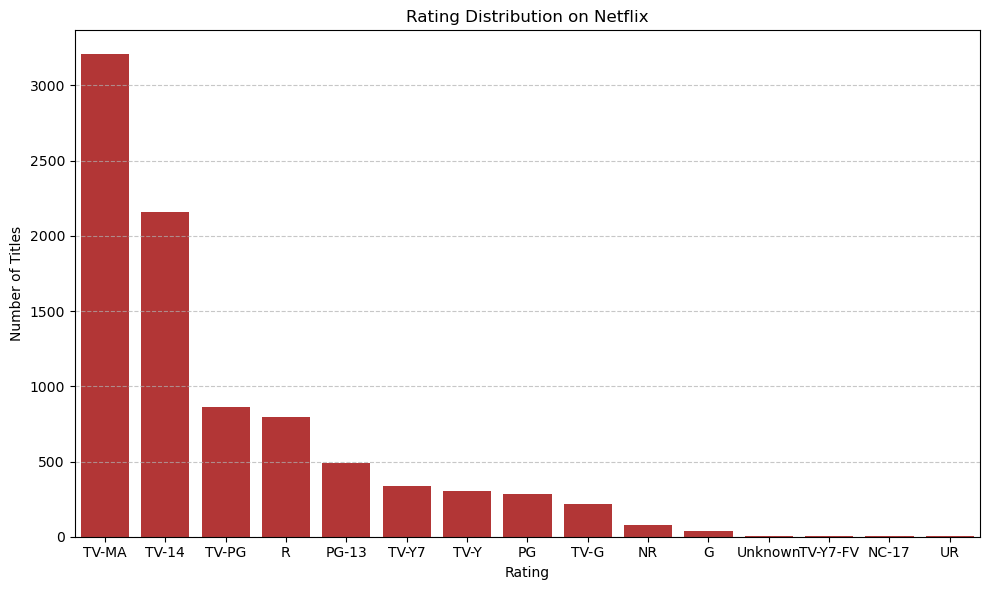

In [89]:
# 1.4. Age-Based Netflix Rating Analysis: Is there enough content for kids and adults? Are there any gaps in the market where we could grow?
# Plot only the rating distribution chart
rating_distribution = df['rating'].value_counts().reset_index()
rating_distribution.columns = ['rating', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_distribution.head(15), x='rating', y='count', color=netflix_palette[0])
plt.title('Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### 1.4. Age-Based Netflix Rating Analysis: Is there enough content for kids and adults? Are there any gaps in the market where we could grow?
###### Dominant Ratings:

-TV-MA (Mature Audience) is the most prevalent rating with over 3,000 titles, indicating Netflix heavily focuses on content for adults.

-TV-14 follows, with around 2,200 titles, still skewing toward older teens and adults.

###### Moderate Presence:

-TV-PG and R ratings (approx. 900 titles each) represent content suitable for families or slightly more mature audiences, but far fewer than TV-MA/TV-14.

-Family & Kids-Oriented Content is Under-Served: The combined number of shows for young children (TV-Y, TV-Y7, PG, G) is very low compared to mature content.

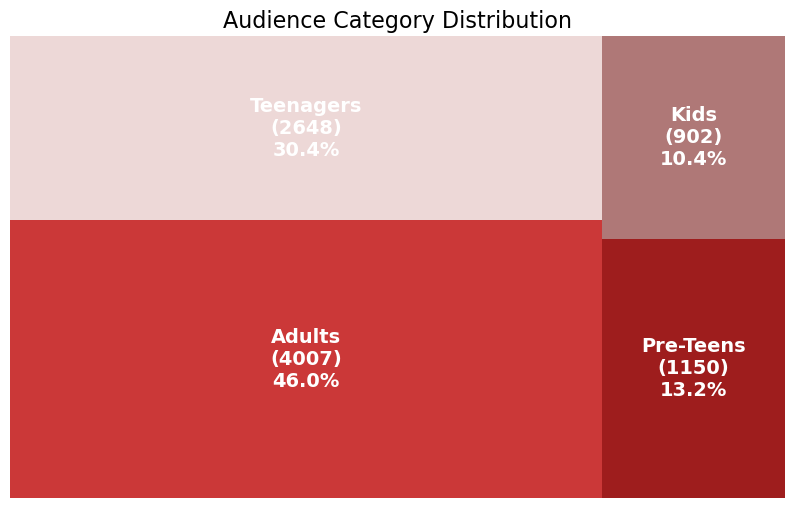

In [95]:
# Count and plot
audience_counts = df[df['audience_category']!='Unrated']['audience_category'].value_counts().reset_index()
audience_counts.columns = ['audience_category', 'count']

# Prepare data
audience_counts['percent'] = (audience_counts['count'] / audience_counts['count'].sum() * 100).round(1)
audience_counts['label'] = audience_counts.apply(
    lambda row: f"{row['audience_category']}\n({int(row['count'])})\n{row['percent']}%", axis=1
)

# Color palette for 5 categories
treemap_colors = netflix_palette[:len(audience_counts)]

# Plot treemap
plt.figure(figsize=(10, 6))
squarify.plot(sizes=audience_counts['count'], label=audience_counts['label'], color=treemap_colors, alpha=0.9, text_kwargs={'fontsize': 14, 'weight': 'bold', 'color': 'white'})
plt.axis('off')
plt.title('Audience Category Distribution', fontsize=16)
plt.show()



- Netflix’s content heavily favors adults and teenagers, with over 76% of titles targeting these groups. Kids and pre-teens are significantly underrepresented, comprising only about 23.6% of the catalog.

##### 1.5. Has there been any recent trend showing that Netflix is shifting its focus more toward kids' content?

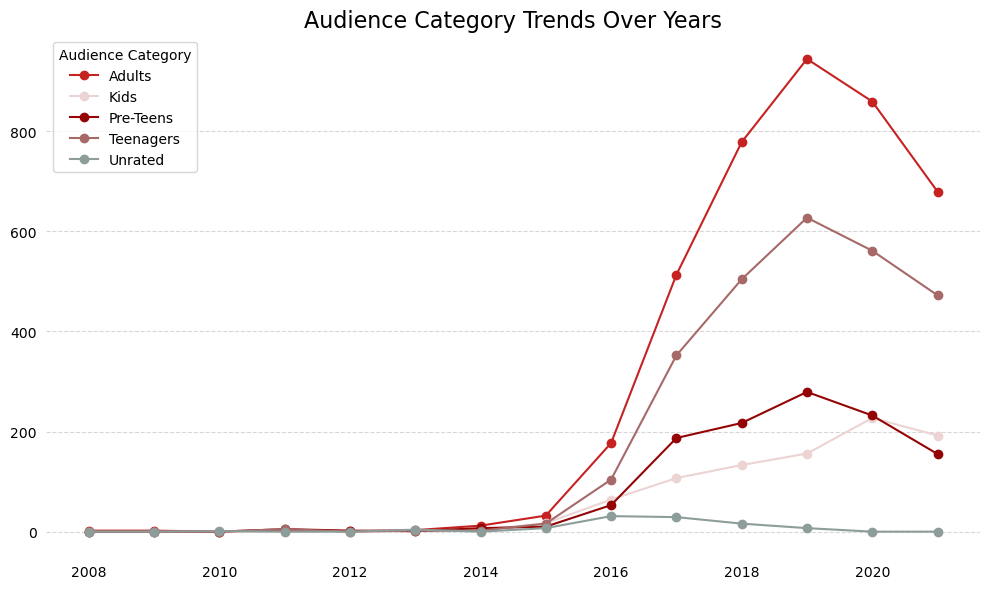

In [96]:
# 1.5. Has there been any recent trend showing that Netflix is shifting its focus more toward kids' content?

yearly_audience = df.groupby(['year_added', 'audience_category']).size().unstack(fill_value=0)

# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
yearly_audience.plot(ax=ax, marker='o',color=netflix_palette)

# Customize appearance
ax.set_title('Audience Category Trends Over Years', fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.legend(title='Audience Category')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- There was no significant growth in kids' content until 2019. While content for all other age groups declined after that point, kids’ content was the only category to continue growing, suggesting a possible strategic shift. This may be linked to the COVID-19 pandemic—when children were home more often, Netflix may have identified this demand and responded accordingly, though further research is needed to confirm this trend.

##### 1.6 Investigate whether there is a relationship between audience age group and genre. Which genres does Netflix focus on for each specific age group?

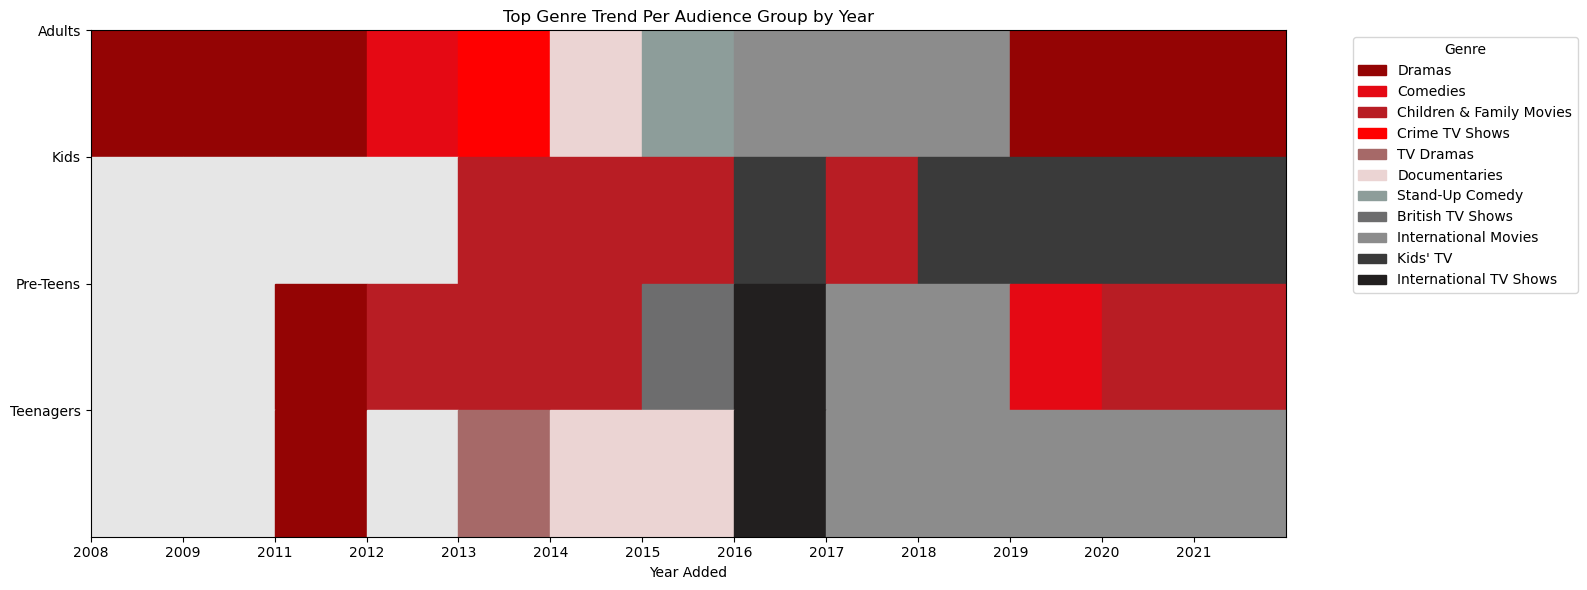

In [97]:
# 1.6. Investigate whether there is a relationship between audience age group and genre. Which genres does Netflix focus on for each specific age group?

audience_genre_yearly = df_exploded[df_exploded['audience_category']!='Unrated'].groupby(['year_added', 'audience_category', 'genres']).size().reset_index(name='count')

# Identify the most popular genre per audience category per year
top_genre_per_year_audience = audience_genre_yearly.loc[
    audience_genre_yearly.groupby(['year_added', 'audience_category'])['count'].idxmax()
]

heatmap_data = top_genre_per_year_audience.pivot(index='audience_category', columns='year_added', values='genres')

unique_genres = pd.unique(top_genre_per_year_audience['genres'])
genre_color_map = {genre: netflix_palette_extended[i % len(netflix_palette_extended)] for i, genre in enumerate(unique_genres)}

# Recreate the heatmap
fig, ax = plt.subplots(figsize=(16, 6))

# Draw colored blocks for each cell
for i, category in enumerate(heatmap_data.index):
    for j, year in enumerate(heatmap_data.columns):
        genre = heatmap_data.loc[category, year]
        color = genre_color_map.get(genre, (0.9, 0.9, 0.9))
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color))

# Tidy up axes
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns.astype(int))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlim(0, len(heatmap_data.columns))
ax.set_ylim(0, len(heatmap_data.index))
ax.invert_yaxis()
ax.set_xlabel("Year Added")
ax.set_title("Top Genre Trend Per Audience Group by Year")

# Create a custom legend
handles = [mpatches.Patch(color=color, label=genre) for genre, color in genre_color_map.items()]
ax.legend(handles=handles, title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


The chart shows Netflix repeatedly using the same genres for each age group over time—like Dramas for adults and Kids’ TV for children. Teenagers experience a genre shift over time, but TV Dramas and International Movies come back multiple times, showing sustained popularity. I believe that the consistency suggests Netflix relies on proven genres to retain viewer engagement.

2. Countries Analysis
* Which country is the most productive in producing Netflix TV Shows and Movies?
* Top 10 countries like TV shows and top 10 countries like Movies

##### 2.1. Which country is the most productive in producing Netflix TV Shows and Movies?

In [98]:
# 2.1. Which country is the most productive in producing Netflix TV Shows and Movies?
# Split country column by comma and explode
df_country_exploded = df[df['country']!='Unknown'].copy()
df_country_exploded['country'] = df_country_exploded['country'].str.split(', ')
df_country_exploded = df_country_exploded.explode('country')

# Count number of titles per country (including co-productions)
country_counts_exploded = df_country_exploded['country'].value_counts().reset_index()
country_counts_exploded.columns = ['Country', 'count']

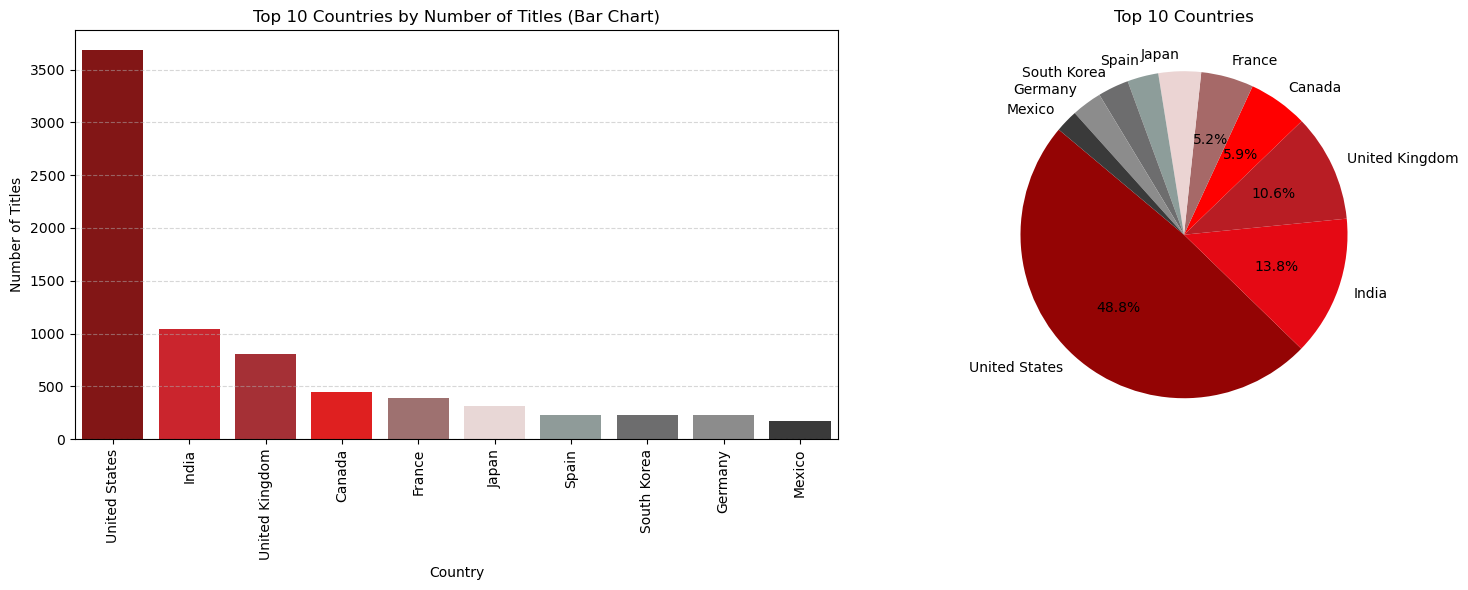

In [99]:
def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

top10 = country_counts_exploded.head(10).copy()  # ensures it's a true copy
top10['Country_for_color'] = top10['Country']

# Plot side-by-side bar and pie charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart (color by hue, but hide legend)
sns.barplot(data=top10,x='Country',y='count',hue='Country_for_color', ax=axes[0],palette=netflix_palette_extended[:10],dodge=False,legend=False)
axes[0].set_title('Top 10 Countries by Number of Titles (Bar Chart)')
axes[0].set_ylabel('Number of Titles')
axes[0].set_xlabel('Country')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=90)

# Pie chart: label only >= 5%
axes[1].pie(top10['count'],labels=top10['Country'],autopct=autopct_format,startangle=140,colors=netflix_palette_extended[:10])
axes[1].set_title('Top 10 Countries')
plt.tight_layout()
plt.show()


##### 2.1. Which country is the most productive in producing Netflix TV Shows and Movies?
###### Both Charts

- The United States completely dominates Netflix’s content catalogue with ~48.8% of all titles (around 2,818 titles).

- India is a clear second but far behind at roughly 13.8% (971 titles).

- English-speaking countries (US, UK, Canada) and major content producers (India, Japan, South Korea) make up the majority of the top 10.

- Many titles have "Unknown" country (830 titles), which is not shown in the charts but is significant.

- Australia does not appear in the Top 10 (only ~87 titles in the full data), meaning Netflix under-invests in AU-specific stories.

###### Bar Chart Analysis (Top 10 Countries by Number of Titles)
- United States leads by a massive margin (~3,650 titles shown in the bar) — almost 3.5x more than India.

- India is second with strong presence (~1,050 titles), reflecting Bollywood and regional Indian content growth on Netflix.

- United Kingdom ranks third (~800 titles), showing solid British TV and movie contributions.

- The drop after the top 3 is steep: Canada (~450), France (~400), Japan (~350), and the rest are below 300.

- The chart highlights Netflix’s heavy reliance on a few major content hubs (mainly English-language + India).

###### Pie Chart Analysis (Top 10 Countries Percentage Share)
- United States takes nearly half the pie (48.8%) — confirming extreme concentration.

- India is the only other country with double-digit share (13.8%).

- United Kingdom follows at 10.6%.

- Smaller but notable shares: Canada (~5.9%), France (~5.2%), with Japan, South Korea, Germany, Spain, and Mexico making up the tail.

- The pie clearly shows Netflix’s catalogue is highly US-centric, with India and UK as important secondary markets.



In [100]:
# 2.2 Top 10 countries like TV shows and top 10 countries like Movies
# Count TV Shows and Movies per country
type_counts = df_country_exploded.groupby(['country', 'type'], observed=True)['title'].count().reset_index()
tv_top_10 = type_counts[type_counts['type'] == 'TV Show'].nlargest(10, 'title').reset_index(drop=True)
display(tv_top_10)
movie_top_10 = type_counts[type_counts['type'] == 'Movie'].nlargest(10, 'title').reset_index(drop=True)
display(movie_top_10)

,country,type,title
0,United States,TV Show,938
1,United Kingdom,TV Show,272
2,Japan,TV Show,199
3,South Korea,TV Show,170
4,Canada,TV Show,126
5,France,TV Show,90
6,India,TV Show,84
7,Taiwan,TV Show,70
8,Australia,TV Show,66
9,Spain,TV Show,61


,country,type,title
0,United States,Movie,2750
1,India,Movie,961
2,United Kingdom,Movie,532
3,Canada,Movie,319
4,France,Movie,303
5,Germany,Movie,182
6,Spain,Movie,171
7,Japan,Movie,119
8,China,Movie,114
9,Mexico,Movie,111


The United States leads in both TV shows and movies, but its dominance in movies (2,750) reflects Hollywood’s strong film industry. Asian countries like Japan and South Korea contribute more proportionally to TV shows, highlighting the popularity of anime and K-dramas. This may suggests Western countries prioritize movie production, while Asia is driving growth in serialized streaming content in last decade.

3. User preference
- Top 10 Directors
- Top 10 Popular Cast Members
- Duration Distribution

##### 3.1 Top 10 Directors

In [101]:
# 3.1. Top 10 Directors
# Exclude rows with missing or 'unknown' directors
known_directors = df[df['director'].notna() & (df['director'].str.strip().str.lower() != 'unknown')]

# Count appearances for each known director
director_counts_cleaned = known_directors['director'].value_counts().reset_index()
director_counts_cleaned.columns = ['director', 'count']

director_country_first = known_directors[
    known_directors['country'].notna() & (known_directors['country'].str.strip().str.lower() != 'unknown')
].drop_duplicates(subset=['director'])[['director', 'country']]

# Merge the director count with their first non-null country
top_directors_with_country = pd.merge(director_counts_cleaned, director_country_first, on='director', how='left')

# Show the top 10
top_directors_with_country.head(10)


,director,count,country
0,Rajiv Chilaka,19,India
1,"Raúl Campos, Jan Suter",18,Mexico
2,Marcus Raboy,16,United States
3,Suhas Kadav,16,India
4,Jay Karas,14,United States
5,Cathy Garcia-Molina,13,Philippines
6,Martin Scorsese,12,United States
7,Jay Chapman,12,United States
8,Youssef Chahine,12,Egypt
9,Steven Spielberg,11,United States


Rajiv Chilaka from India directed the most titles (19), followed by Raúl Campos and Jan Suter from Mexico (18). The United States has the most directors in the top 10, with five entries including Martin Scorsese and Steven Spielberg. Directors from India, Mexico, the Philippines, and Egypt also appear, showing strong international representation.

##### 3.2 Top 10 popular cast

In [102]:
# Remove 'Unknown' and NaN values from the cast column
df_cast_exploded = df[df['cast'].notna() & (df['cast'].str.strip().str.lower() != 'unknown')].copy()
df_cast_exploded['cast'] = df_cast_exploded['cast'].str.split(', ')
df_cast_exploded = df_cast_exploded.explode('cast')

# Clean up whitespace and filter out any lingering 'Unknown'
df_cast_exploded['cast'] = df_cast_exploded['cast'].str.strip()
df_cast_exploded = df_cast_exploded[df_cast_exploded['cast'].str.lower() != 'unknown']

# Count appearances
cast_counts_cleaned = df_cast_exploded['cast'].value_counts().reset_index()
cast_counts_cleaned.columns = ['cast', 'count']

cast_country_first = df_cast_exploded[df_cast_exploded['country'].notna() & 
                    (df_cast_exploded['country'].str.strip().str.lower() != 'unknown')].drop_duplicates(subset=['cast'])[['cast', 'country']]

# Merge cast count with country
top_cast_with_country = pd.merge(cast_counts_cleaned, cast_country_first, on='cast', how='left')

# Show top 10 with country
top_cast_with_country.head(10)

,cast,count,country
0,Anupam Kher,43,India
1,Shah Rukh Khan,35,India
2,Julie Tejwani,33,India
3,Naseeruddin Shah,32,India
4,Takahiro Sakurai,32,Japan
5,Rupa Bhimani,31,India
6,Akshay Kumar,30,India
7,Om Puri,30,India
8,Yuki Kaji,29,Japan
9,Paresh Rawal,28,India


Anupam Kher appears in the most titles (43), followed by Shah Rukh Khan (35) and Julie Tejwani (33), all from India. Eight out of the top ten most frequent cast members are from India. Only two actors, Takahiro Sakurai and Yuki Kaji, represent Japan in the top ten.

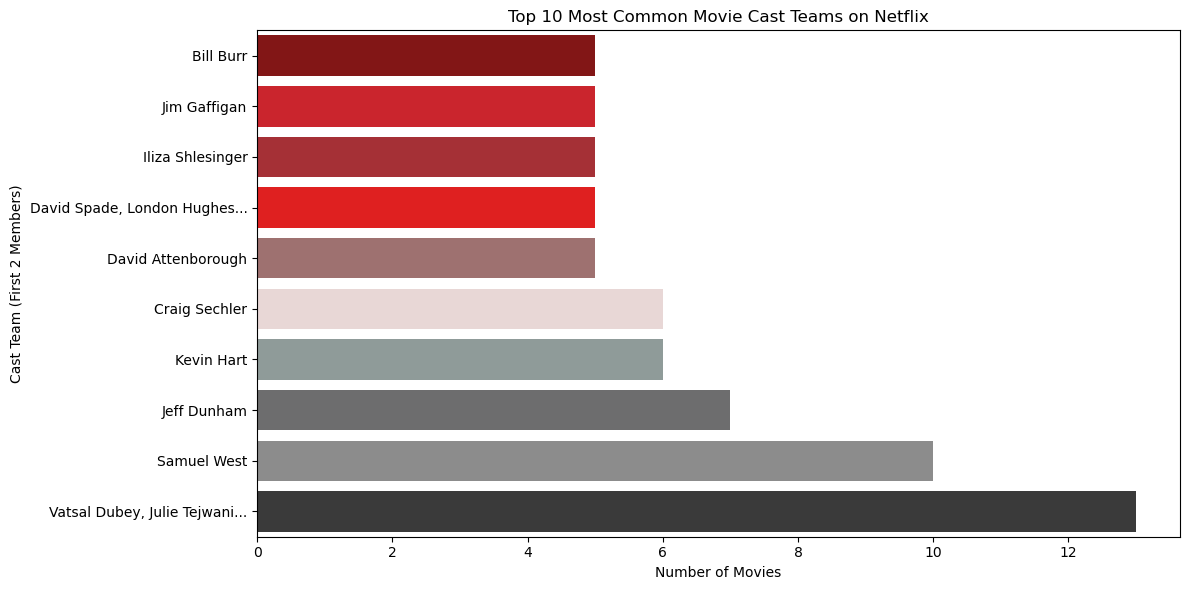

In [103]:
# Extract full cast team strings for each movie and count occurrences
movie_df = df[(df['type'] == 'Movie') & (df['cast'] != 'Unknown')].copy()
movie_df = movie_df.dropna(subset=['cast'])

# Count how many times each unique cast team (full string) appears
cast_teams = movie_df['cast'].value_counts().reset_index()
cast_teams.columns = ['Cast Team', 'Movie Count']

# Create a shortened version of cast teams for display
cast_teams['Cast Label'] = cast_teams['Cast Team'].apply(lambda x: ', '.join(x.split(', ')[:2]) + '...' if len(x.split(', ')) > 2 else x)

# Prepare top 10 with short labels
top_cast_teams = cast_teams.head(10).sort_values(by='Movie Count')

# Plot with hue using the original team name (for color differentiation)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_cast_teams, y='Cast Label', x='Movie Count', hue='Cast Label', dodge=False, palette=netflix_palette_extended[:10])
plt.title('Top 10 Most Common Movie Cast Teams on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Cast Team (First 2 Members)')
plt.tight_layout()
plt.show()



Some cast members may appear in multiple titles due to recurring minor roles or consistent casting in lead roles, making it hard to distinguish their impact at a glance. However, the data shows that popular directors and frequently featured cast can play a key role in content visibility and reach. Leveraging famous talent could be a strategic advantage for future investments, helping us create standout productions that rival Netflix.

##### 3.3. Duration Distribution

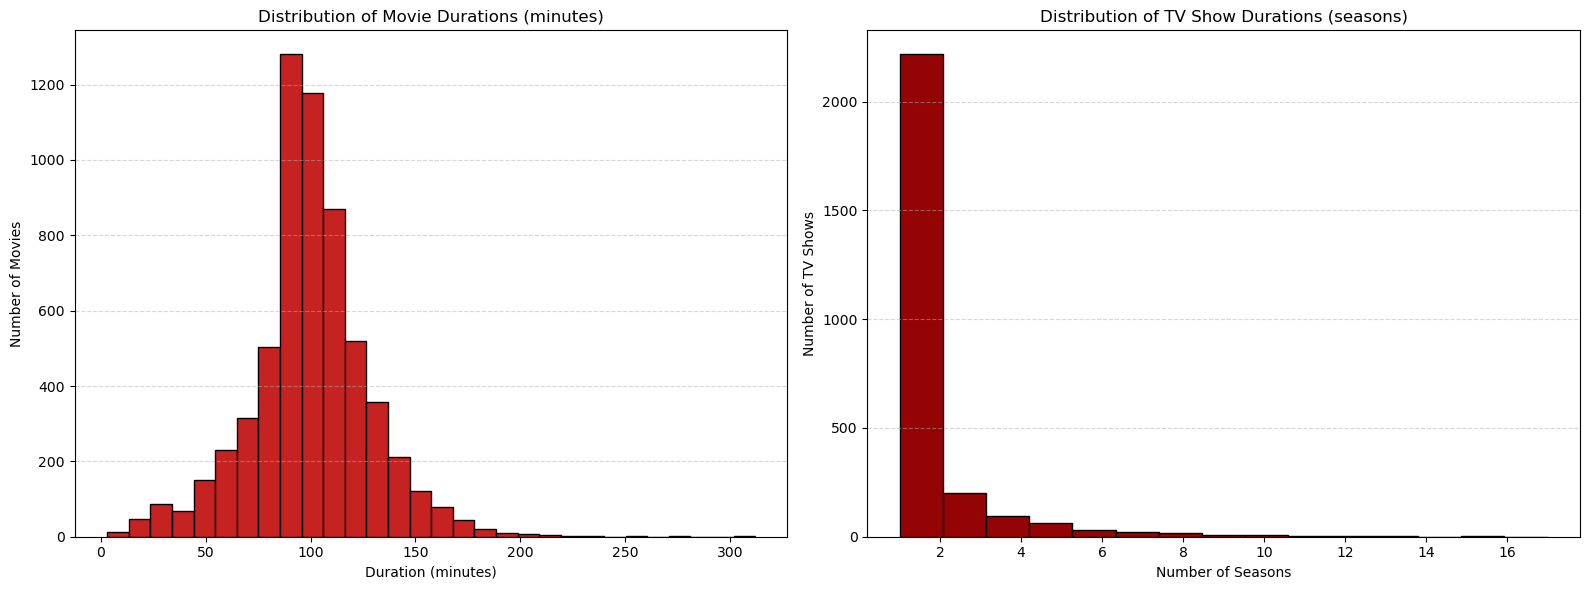

In [104]:
# 3.3. Duration Distribution
# Separate Movies and TV Shows
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()
movies['duration_minutes'] = movies['duration'].str.extract(r'(\d+)').astype(float)
tv_shows['duration_seasons'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)

# Plot charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(movies['duration_minutes'].dropna(), bins=30, color=netflix_palette[0], edgecolor='black')
axes[0].set_title('Distribution of Movie Durations (minutes)')
axes[0].set_xlabel('Duration (minutes)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Number of Movies')

axes[1].hist(tv_shows['duration_seasons'].dropna(), bins=15, color=netflix_palette[2], edgecolor='black')
axes[1].set_title('Distribution of TV Show Durations (seasons)')
axes[1].set_xlabel('Number of Seasons')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Number of TV Shows')
plt.tight_layout()
plt.show()


###### Distribution of Movie Durations (Left Chart)

- Peak Concentration: Most movies are clustered between 80–120 minutes, with the highest number around 90–100 minutes (standard feature film length).
Bell-Shaped Distribution: The chart shows a clear normal-like distribution centered around 90–110 minutes, indicating Netflix prefers conventional movie lengths.

- Short Movies: Very few movies under 60 minutes (likely short films or specials).

- Long Movies: Sharp drop after 150 minutes — only a small number exceed 2 hours, and almost none go beyond 200 minutes.

- Insight: Netflix’s movie catalogue is dominated by standard-length feature films (roughly 1.5–2 hours), making binge-watching easier but limiting experimental or very long formats.

###### Distribution of TV Show Durations (Right Chart)

- Heavy Skew Toward Short Runs: The vast majority of TV shows have only 1–2 seasons (over 2,200 shows with 2 seasons or fewer).

- Rapid Decline: Number of shows drops sharply after 2 seasons. Very few titles reach 6+ seasons, and almost none go beyond 10 seasons.

- One-Season Dominance: The tallest bar is at 2 seasons, followed by a steep fall — suggesting many shows are either cancelled early or are limited series.

- Long-Running Shows Are Rare: Only a tiny fraction have 8+ seasons (long-running hits like "The Great British Baking Show" are exceptions).
Insight: Netflix relies heavily on short-season or limited series rather than building many long-running franchises.

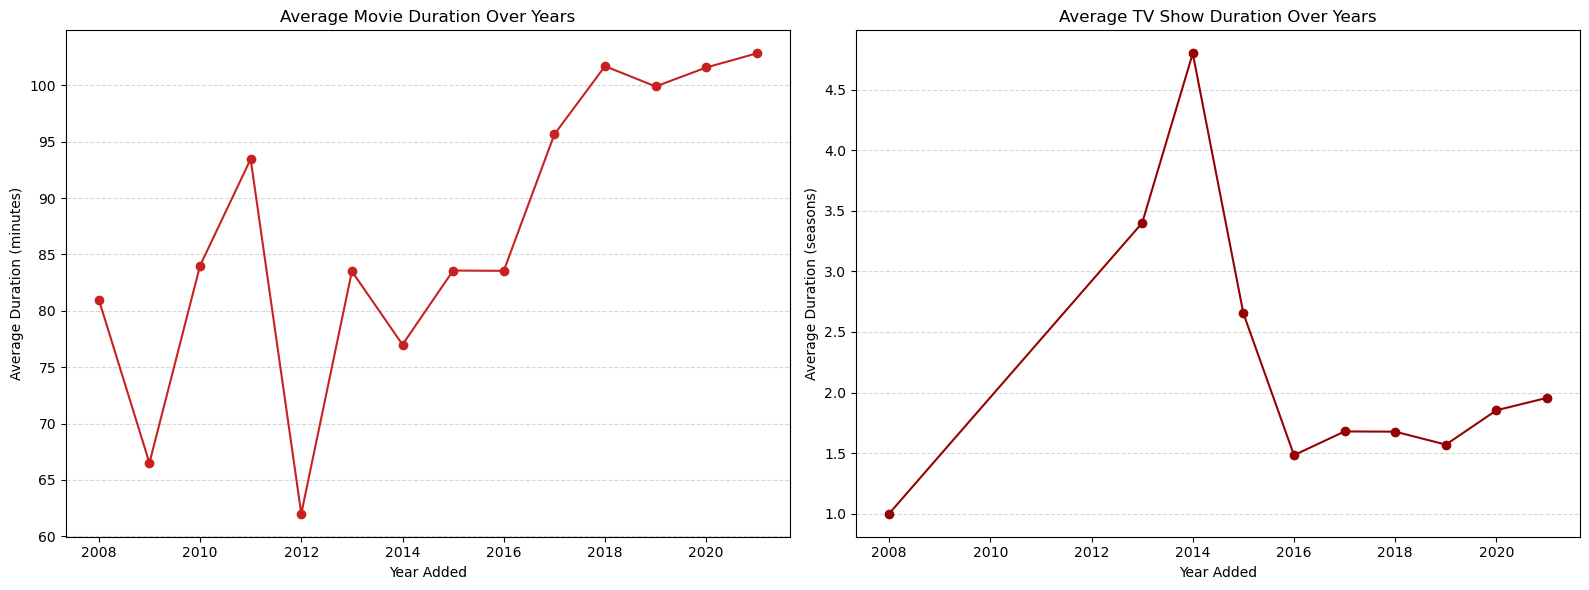

In [105]:
# Group by year and compute average duration
movie_duration_by_year = movies.dropna(subset=['year_added']).groupby('year_added')['duration_minutes'].mean()
tv_duration_by_year = tv_shows.dropna(subset=['year_added']).groupby('year_added')['duration_seasons'].mean()

# Plotting two separate charts side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Movies: Average duration in minutes over years
axes[0].plot(movie_duration_by_year.index, movie_duration_by_year.values, marker='o', color=netflix_palette[0])
axes[0].set_title('Average Movie Duration Over Years')
axes[0].set_xlabel('Year Added')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Average Duration (minutes)')

# TV Shows: Average number of seasons over years
axes[1].plot(tv_duration_by_year.index, tv_duration_by_year.values, marker='o', color=netflix_palette[2])
axes[1].set_title('Average TV Show Duration Over Years')
axes[1].set_xlabel('Year Added')
axes[1].set_ylabel('Average Duration (seasons)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


###### Average Movie Duration Over Years (Left Chart)

- High Volatility in Early Years (2008–2013): Movie lengths fluctuated significantly — dropping as low as 62 minutes in 2012, then jumping to 93 minutes in 2011.

- Stabilization & Upward Trend (2016 onward): From 2016, average movie duration rose steadily and stabilized around 100–104 minutes.

- Recent Trend: Movies added in 2020–2021 have the longest average duration (~103–105 minutes).

- Insight: Netflix has shifted toward longer, more standard feature films (closer to 100+ minutes) in recent years, moving away from shorter or experimental lengths.

###### Average TV Show Duration Over Years (Right Chart)

- Strong Growth Phase (2008–2014): Average number of seasons increased dramatically from 1.0 in 2008 to a peak of 4.7 seasons in 2015.

- Sharp Decline After Peak: After 2015, average seasons per TV show dropped steeply to around 1.5 seasons by 2017.

- Stabilization at Lower Level: Since 2017, the average has remained low and stable between 1.5 – 2.0 seasons.

- Insight: Netflix heavily favored longer-running series in the early 2010s, but has since shifted strongly toward short-run or limited series (1–2 seasons).

4. Time Series Analysis
- Heatmap Time Analysis
- Time Gap Between Release Date and Netflix Added Date

##### 4.1. Heatmap Time Analysis

In [106]:
# Create custom Netflix-style colormap (light gray to red to dark red) and Month order
netflix_cmap = LinearSegmentedColormap.from_list(
    "netflix", ["#f5f5f1", "#e50914", "#940404"]
)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']


In [107]:
monthly_adds = df.groupby(['month_added', 'year_added']).size().reset_index(name='count')
monthly_pivot = monthly_adds.pivot(index='month_added', columns='year_added', values='count').reindex(month_order)
monthly_pivot.columns = monthly_pivot.columns.astype(int)

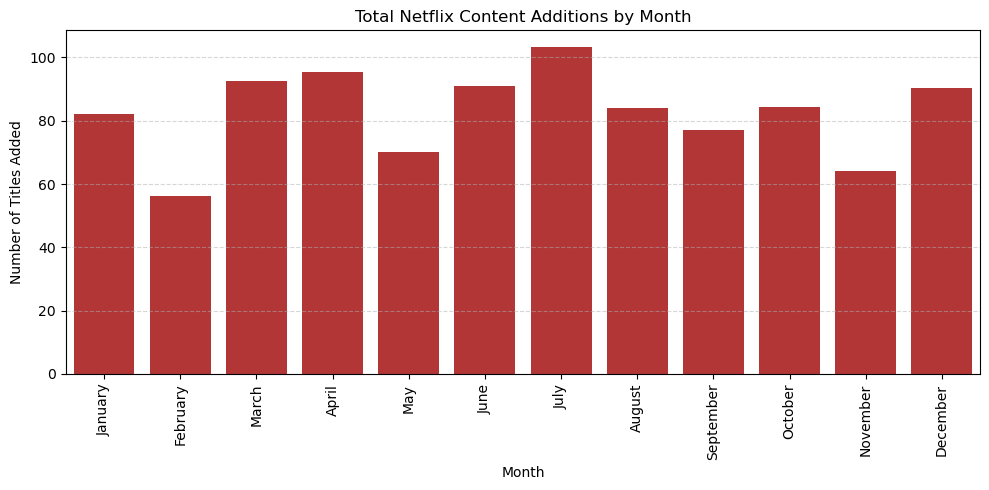

In [109]:
# Sum across all years to get total content added per month (regardless of year)
monthly_totals = monthly_pivot.mean(axis=1).reindex(month_order)
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_totals.index, y=monthly_totals.values, color=netflix_palette[0])
plt.title("Total Netflix Content Additions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### Highest Additions:
- July is the strongest month (~102 titles added on average).

- April and March are also very high (~95 titles).

- December and June are solid high months (~90 titles).

##### Lowest Additions:
- February is the weakest month by far (~57 titles).

- May and November are also relatively low (~70 and ~64 titles).

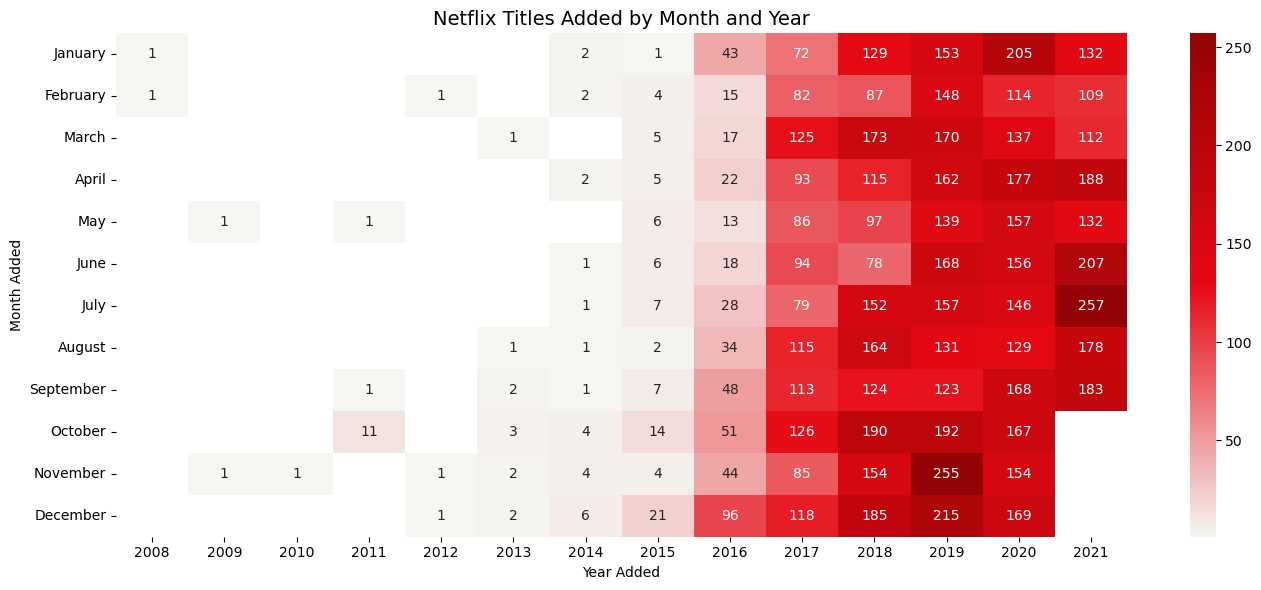

In [110]:
# Plot the heatmap without grid lines and clean year labels
plt.figure(figsize=(14, 6))
sns.heatmap(monthly_pivot,cmap=netflix_cmap,annot=True,fmt='.0f',linewidths=0,linecolor='white',cbar=True)
plt.title('Netflix Titles Added by Month and Year', fontsize=14)
plt.xlabel('Year Added')
plt.ylabel('Month Added')
plt.tight_layout()
plt.show()

- December, November, and July consistently show the highest content additions across recent years, making them ideal months for maximum visibility during peak user engagement periods (holidays and mid-year).

- December had the strongest spike overall (e.g., 215 titles in 2019, 169 in 2020), indicating Netflix aligns major releases with the holiday binge-watching season.

- Months like April and October are also strong contenders, often exceeding 150 additions, making them optimal for pre-holiday or fall release windows.

##### 4.2. Time gap between Released Date and Date Added

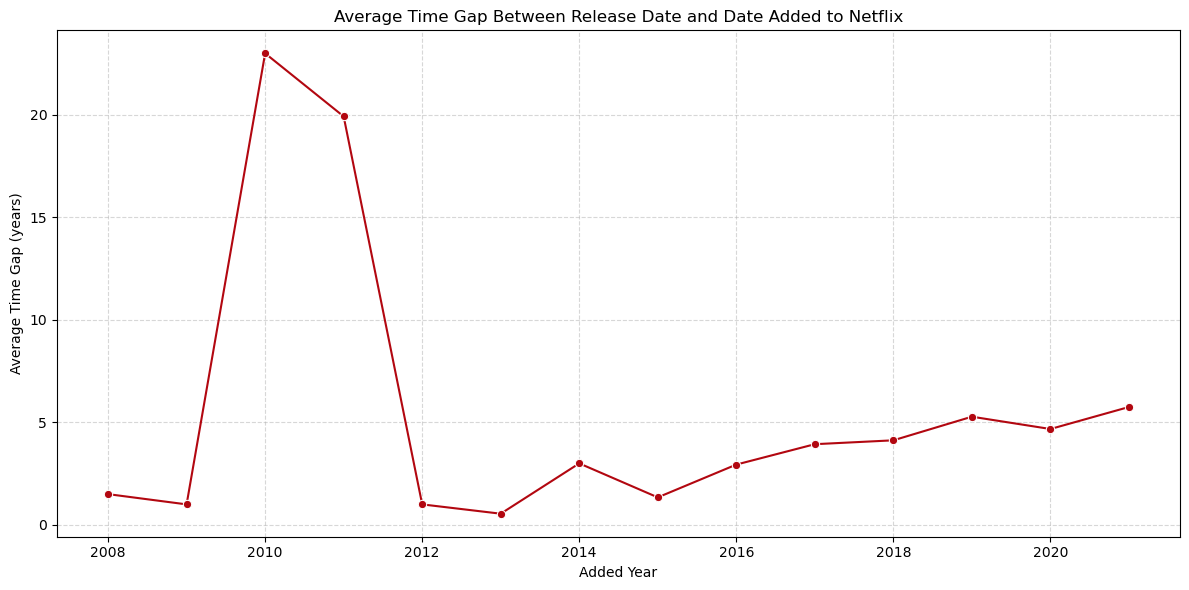

In [111]:
df['time_gap'] = (df['year_added'] - df['release_year'])

# Group by release year and calculate average time gap
avg_gap_by_release_year = df.dropna(subset=['year_added', 'time_gap']).groupby('year_added')['time_gap'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_gap_by_release_year, x='year_added', y='time_gap', marker='o', color='#b20710')
plt.title('Average Time Gap Between Release Date and Date Added to Netflix')
plt.xlabel('Added Year')
plt.ylabel('Average Time Gap (years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### Extreme Volatility in Early Years (2008–2012):
- The gap was very small in 2008–2009 (~1–1.5 years).

- It spiked dramatically in 2010 to a peak of ~23 years (Netflix was adding many old/classic titles).

- Sharp decline after 2010, dropping to nearly 1 year by 2012.

##### Stabilization After 2012:
- From 2013 onward, the average time gap became much smaller and more stable.

- Between 2013–2016, the gap stayed low (mostly 1–3 years).

##### Gradual Increase in Recent Years (2017–2021):
- The average gap started rising again from 2017.

- By 2020–2021, the average time gap reached ~5–6 years.

##### Overall Trend:
- Early Netflix (2008–2012) relied heavily on catalogue filling with old content (large gaps).

- Mid-period (2013–2016) focused more on recent releases.

- Recent years (2018–2021) show Netflix adding more older content again (average delay of 5+ years).

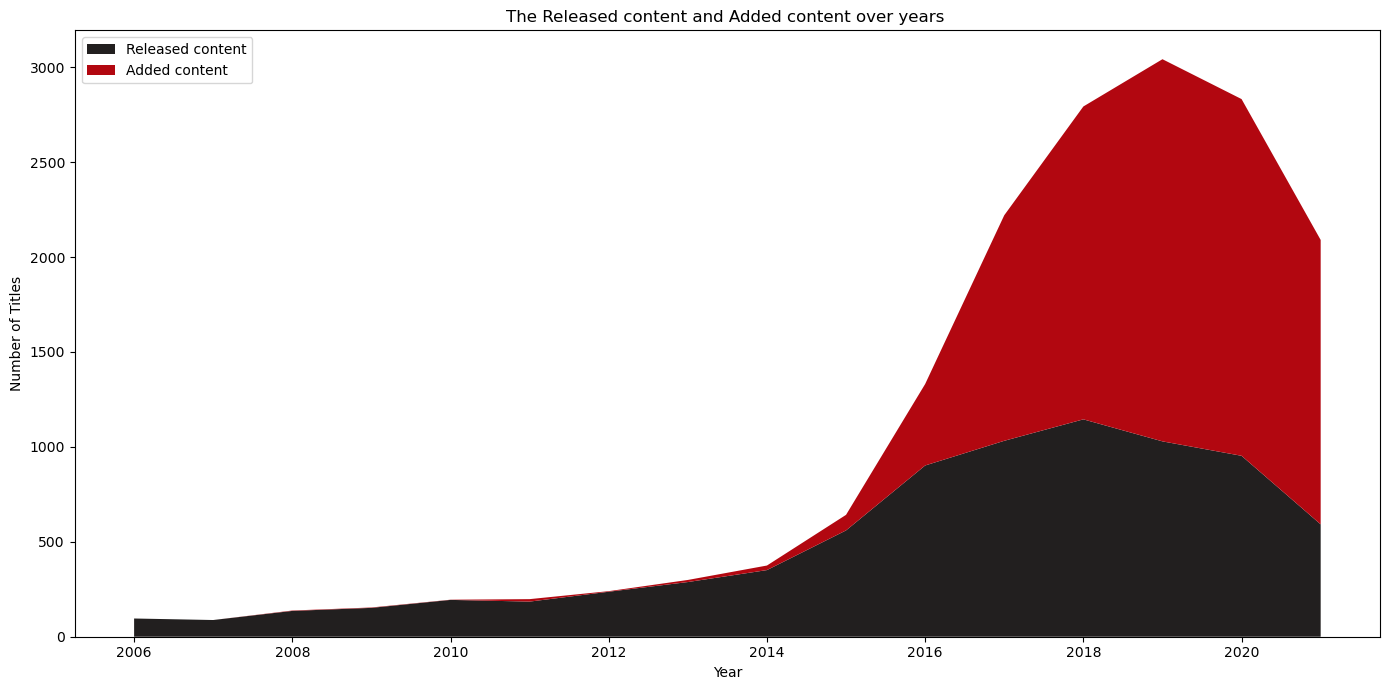

In [112]:
# Count titles by added year and release year
added_years = df['date_added'].dt.year.value_counts().sort_index()
released_years = df['release_year'].value_counts().sort_index()

# Merge into one DataFrame
years = sorted(set(added_years.index).union(set(released_years.index)))
yearwise = pd.DataFrame({'year': years})
yearwise['added'] = yearwise['year'].map(added_years).fillna(0).astype(int)
yearwise['released'] = yearwise['year'].map(released_years).fillna(0).astype(int)

# Filter for reasonable modern era
yearwise = yearwise[yearwise['year'] >= 2006]

yearwise_clean = yearwise.copy()
yearwise_clean['year'] = pd.to_numeric(yearwise_clean['year'], errors='coerce')
yearwise_clean['released'] = pd.to_numeric(yearwise_clean['released'], errors='coerce')
yearwise_clean['added'] = pd.to_numeric(yearwise_clean['added'], errors='coerce')
yearwise_clean = yearwise_clean.dropna()
year = yearwise_clean['year'].to_numpy(dtype='int')
released = yearwise_clean['released'].to_numpy(dtype='int')
added = yearwise_clean['added'].to_numpy(dtype='int')

# Plot fixed stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(year,released,added,labels=['Released content', 'Added content'],colors=['#221f1f', '#b20710'])
plt.title("The Released content and Added content over years ")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(False)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### Two Distinct Areas:
- Black area (Released content): Shows the original release year of the titles.

- Red area (Added content): Shows when Netflix actually added those titles to its platform.

##### Early Years (2006–2014):
- Very little content overall.

- Released and Added lines almost overlap → Netflix was mostly adding recently released titles.

##### Explosive Growth Phase (2015–2019):
- Massive increase in content additions starting around 2015.

- Red area grows much faster than black area → Netflix began aggressively adding older catalogue titles (large gap between release year and addition year).

- Peak additions occurred in 2019 (~3,000 titles added in one year).

##### Recent Trend (2020–2021):
- Sharp decline in new additions after the 2019 peak.

- The gap between black (released) and red (added) remains significant, meaning Netflix continued filling its library with older content even as overall growth slowed.

##### Overall Pattern:
- Netflix started with a "new release" strategy but quickly shifted to a "catalogue expansion" model by adding many older movies and shows.

- The biggest growth spurt happened between 2016 and 2019.

In [78]:
# df.to_csv("check.csv", index=False)